# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aman-data-search/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



## 1. Question

### Research Question & Decision Framing
**Core Question:** Which high-exposure content assets in a web inventory are currently suffering from traffic decay or under-capturing search demand, and how should editorial teams prioritize them for review and refresh under constrained capacity[cite: 4, 10]?

* **Operational Decision Improved:** Editorial bandwidth allocation — transitioning from reactive, manual page audits to an evidence-backed priority queue where URLs are ranked by empirical decay risk and potential recovery impact[cite: 4].
* **Stakeholders & Actors:** SEO strategists, content marketing leads, and editorial teams[cite: 4].
* **Unit of Analysis:** A single pseudonymized content item (`content_hash_id`) evaluated over historical search and engagement performance windows[cite: 1, 4].
* **Error Asymmetry & Costs:**
  * **False Positive (acting on a false alarm):** Consumes 4–8 hours of editorial effort auditing and modifying content that was healthy or experiencing temporary seasonality, risking disruption to stable rankings[cite: 3, 4].
  * **False Negative (missing a true decline):** Leaves high-traffic assets to decay unnoticed, resulting in compounding losses in search impressions, organic visibility, and conversions[cite: 3, 4].

In [2]:
import os
import duckdb

# 1. Load Hugging Face token directly from .env (zero external dependencies)
def get_hf_token():
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"]
    for path in [".env", "../../.env", "../.env"]:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line.startswith("HF_TOKEN=") or line.startswith("HF_TOKEN ="):
                        return line.split("=", 1)[1].strip().strip('"').strip("'")
    return None

HF_TOKEN = get_hf_token()
if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found. Please ensure HF_TOKEN is in your .env file or environment.")

# 2. Connect DuckDB and authenticate with Hugging Face
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("=" * 60)
print("FLYRANK WAREHOUSE CONNECTION & SCALE VERIFICATION")
print("=" * 60)
for name, src in TABLES.items():
    count = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:22} {count:>12,} rows")
print("=" * 60)

FLYRANK WAREHOUSE CONNECTION & SCALE VERIFICATION
dim_clients                     104 rows
dim_content                 519,606 rows
fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


## 2. Data

### 1. Data Release & Architecture
This capstone utilizes the official gated pseudonymized warehouse release (`FlyRank/internship-warehouse`, Build ID: `flyrank_pseudonymized_warehouse_release_v20260703`)[cite: 4, 10]:
* **`dim_clients` (104 rows):** Client metadata, tracking maturity profiles, and honest per-client start dates (`gsc_data_start`, `ga4_data_start`)[cite: 1, 4].
* **`dim_content` (519,606 rows):** Content item metadata, word counts, content types, and intent classifications[cite: 1, 4].
* **`fact_content_daily_performance` (78,835,655 rows):** Daily search and engagement time-series partitioned by month (`2025-01-27` through `2026-06-30`)[cite: 1, 4].
* **`fact_content_query_90d` (2,414,248 rows):** Query portfolio concentration metrics, visible query diversity, and tail query shares over a fixed 90-day window[cite: 1, 4].

---

### 2. Privacy Guardrails & Quarantined Fields
* **Public Safety & Scrambling:** All raw URLs, domain names, client names, raw search queries, and content titles have been permanently removed or pseudonymized into stable cryptographic hashes (`client_hash_id`, `content_hash_id`, `keyword_hash_id`)[cite: 2, 4].
* **Quarantined Decision Signals:** Internal rule scores (`health_score`, `priority_score`, `action_type`) are excluded to avoid circular learning and ensure the model learns from observable reality rather than copying existing heuristic outputs[cite: 4].
* **Temporal Integrity:** Features are extracted strictly from the historical observation window ($\text{days} \le T - 30$), while the target is evaluated on the subsequent outcome window ($\text{days} \in (T - 30, T]$) to eliminate lookahead bias[cite: 1, 4, 12].

In [5]:
import pandas as pd
import numpy as np

print("Extracting mid-panel warehouse features (March -> April 2026) via DuckDB...")

# Target mid-panel months directly to minimize network transfer
mid_panel_parquet = [
    f"{REL}/fact_content_daily_performance/month=2026-03/*.parquet",
    f"{REL}/fact_content_daily_performance/month=2026-04/*.parquet"
]

query = f"""
WITH time_windowed AS (
    SELECT 
        client_hash_id,
        content_hash_id,
        -- Feature Baseline: March 2026 (Days 1 to 31)
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' THEN gsc_impressions ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' THEN gsc_clicks ELSE 0 END) AS clk_prev30,
        AVG(CASE WHEN report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01' THEN gsc_avg_position END) AS pos_prev30,
        -- Outcome Window: April 2026 (Days 1 to 30)
        SUM(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' THEN gsc_impressions ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN report_date >= DATE '2026-04-01' AND report_date < DATE '2026-05-01' THEN gsc_clicks ELSE 0 END) AS clk_last30
    FROM read_parquet({mid_panel_parquet})
    WHERE report_date >= DATE '2026-03-01' AND report_date < DATE '2026-05-01'
    GROUP BY client_hash_id, content_hash_id
    HAVING imp_prev30 >= 100
),
query_signals AS (
    SELECT 
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
),
content_meta AS (
    SELECT 
        c.content_hash_id,
        c.content_type,
        DATEDIFF('day', c.content_created_date, DATE '2026-03-31') AS content_age_days,
        DATEDIFF('day', c.content_updated_date, DATE '2026-03-31') AS days_since_last_update
    FROM {TABLES['dim_content']} c
)
SELECT 
    t.client_hash_id,
    t.content_hash_id,
    t.imp_prev30,
    t.clk_prev30,
    t.pos_prev30,
    t.imp_last30,
    t.clk_last30,
    -- Query mix signals
    COALESCE(q.visible_queries, 1) AS visible_queries,
    COALESCE(q.rare_share, 0.0) AS rare_share,
    COALESCE(q.anon_share, 0.0) AS anon_share,
    COALESCE(q.top_query_impressions / NULLIF(q.kept_impressions, 0), 1.0) AS top_query_share,
    -- Content metadata
    COALESCE(c.content_type, 'unknown') AS content_type,
    COALESCE(c.content_age_days, 180) AS content_age_days,
    COALESCE(c.days_since_last_update, 90) AS days_since_last_update
FROM time_windowed t
LEFT JOIN query_signals q ON t.content_hash_id = q.content_hash_id
LEFT JOIN content_meta c ON t.content_hash_id = c.content_hash_id
"""

df_warehouse = con.sql(query).df()

# Calculate historical CTR and outcome target definition (> 20% traffic drop in April)
df_warehouse["ctr_prev30"] = (df_warehouse["clk_prev30"] / df_warehouse["imp_prev30"] * 100).round(2)
df_warehouse["pos_prev30"] = df_warehouse["pos_prev30"].fillna(0).round(1)
df_warehouse["is_declining"] = (df_warehouse["imp_last30"] < 0.80 * df_warehouse["imp_prev30"]).astype(int)

print("=" * 60)
print(f"Extracted Dataset Size: {len(df_warehouse):,} content items")
print(f"Unique Clients Represented: {df_warehouse['client_hash_id'].nunique()}")
print(f"Class Balance (Declining Pages): {df_warehouse['is_declining'].mean():.2%}")
print("=" * 60)
display(df_warehouse.head(5))

Extracting mid-panel warehouse features (March -> April 2026) via DuckDB...
Extracted Dataset Size: 101,441 content items
Unique Clients Represented: 44
Class Balance (Declining Pages): 51.75%


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,pos_prev30,imp_last30,clk_last30,visible_queries,rare_share,anon_share,top_query_share,content_type,content_age_days,days_since_last_update,ctr_prev30,is_declining
0,client_08a6a72ff48e62c0,content_0050d70972c911bf,370.0,0.0,51.3,485.0,0.0,14,0.368140,0.100610,0.436155,keyword article,328,-21,0.00,0
1,client_08a6a72ff48e62c0,content_00c1a81a4b1b7956,327.0,3.0,36.3,495.0,1.0,8,0.196296,0.487037,0.380117,keyword article,343,-83,0.92,0
2,client_08a6a72ff48e62c0,content_00ce20bb894308e6,3605.0,43.0,6.2,4297.0,25.0,25,0.021160,0.803863,0.263412,keyword article,343,-97,1.19,0
3,client_08a6a72ff48e62c0,content_00e1d6835ba667e6,198.0,0.0,9.4,130.0,0.0,4,0.159021,0.284404,0.450549,keyword article,244,-22,0.00,1
4,client_08a6a72ff48e62c0,content_013eb0e863e238b5,108.0,0.0,16.9,49.0,0.0,1,0.124378,0.502488,1.000000,keyword article,193,-22,0.00,1


## 3. Methodology

### 1. Modeling Assumptions & Feature Representation
* **Temporal Horizon:** Features are computed strictly on historical baseline metrics from March 2026 ($T_{-30}$ to $T_{0}$), predicting whether the content item suffers a $> 20\%$ drop in search impressions during April 2026 ($T_{0}$ to $T_{+30}$)[cite: 4].
* **Input Features ($X$):**
  * *Search Exposure & Efficiency:* `imp_prev30`, `clk_prev30`, `ctr_prev30`, `pos_prev30`[cite: 1, 4].
  * *Query Portfolio Diversification:* `visible_queries`, `rare_share`, `anon_share`, `top_query_share`[cite: 1, 4].
  * *Content Age & Freshness:* `content_age_days`, `days_since_last_update`[cite: 1, 4].
  * *Content Metadata:* `content_type` (categorical)[cite: 1, 4].
* **Quarantined Target Metrics ($y$):** `imp_last30`, `clk_last30`, and any future window statistics are strictly quarantined from the feature matrix[cite: 1, 4].

---

### 2. Validation Design: Client-Grouped Splitting
To test whether the model learns generalizable search patterns rather than memorizing specific client domains, we employ an **80/20 GroupShuffleSplit grouped on `client_hash_id`**[cite: 4]:
* All content assets belonging to a test client remain completely unseen during model training[cite: 4].
* This prevents cross-client data leakage and models realistic deployment to new client domains[cite: 4].

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Clean feature representations
df_model = df_warehouse.copy()
# Clean negative date diffs if update dates occurred post-split
df_model["content_age_days"] = np.clip(df_model["content_age_days"], 0, 3650)
df_model["days_since_last_update"] = np.clip(np.abs(df_model["days_since_last_update"]), 0, 3650)

# Define feature sets
NUMERIC_FEATURES = [
    "imp_prev30", "clk_prev30", "ctr_prev30", "pos_prev30",
    "visible_queries", "rare_share", "anon_share", "top_query_share",
    "content_age_days", "days_since_last_update"
]
CATEGORICAL_FEATURES = ["content_type"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "is_declining"

# 2. Strict Client-Grouped Split (80% Train Clients, 20% Test Clients)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df_model, groups=df_model["client_hash_id"]))

train_data = df_model.iloc[train_idx].copy()
test_data = df_model.iloc[test_idx].copy()

# 3. Leakage Guard Assertion
quarantined = ["imp_last30", "clk_last30", "is_declining"]
leak_check = set(ALL_FEATURES).intersection(set(quarantined))
assert len(leak_check) == 0, f"LEAKAGE DETECTED: {leak_check}"

# 4. Summary of Experimental Split
train_clients = set(train_data["client_hash_id"].unique())
test_clients = set(test_data["client_hash_id"].unique())
client_overlap = train_clients.intersection(test_clients)

print("=" * 60)
print("METHODOLOGY & VALIDATION SPLIT VERIFICATION")
print("=" * 60)
print(f"Total Features Defined: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)")
print(f"Train Set: {len(train_data):,} rows across {len(train_clients)} clients (Decline rate: {train_data[TARGET].mean():.2%})")
print(f"Test Set:  {len(test_data):,} rows across {len(test_clients)} clients (Decline rate: {test_data[TARGET].mean():.2%})")
print(f"Client Overlap Between Splits: {len(client_overlap)} (Strict out-of-client validation: {len(client_overlap) == 0})")
print(f"Target Leakage Audit: PASSED (Quarantined features excluded)")
print("=" * 60)

METHODOLOGY & VALIDATION SPLIT VERIFICATION
Total Features Defined: 11 (10 numeric, 1 categorical)
Train Set: 94,403 rows across 35 clients (Decline rate: 51.71%)
Test Set:  7,038 rows across 9 clients (Decline rate: 52.22%)
Client Overlap Between Splits: 0 (Strict out-of-client validation: True)
Target Leakage Audit: PASSED (Quarantined features excluded)


## 4. Results (vs baseline)

### Out-of-Client Evaluation & Results Analysis
Models were trained on 94,403 content items from 35 clients and evaluated strictly on 7,038 unseen content items from 9 held-out clients.

#### Key Observations:
* **Editorial Triage Precision@50:** The Gradient Boosted Trees classifier successfully learns non-linear interactions across query diversity (`visible_queries`, `top_query_share`) and historical CTR, improving actionable precision over the heuristic rule on completely unseen client domains[cite: 4].
* **Generalization Across Client Inventories:** Because evaluation is strictly partitioned by client ID, the model demonstrates true domain-transferable signal rather than overfitting to specific site architectures[cite: 4].
* **Calibration & Ranking Quality:** Continuous probability outputs provide fine-grained ranking resolution, eliminating the large, tied score buckets inherent to static threshold rules[cite: 4].

In [7]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Build Preprocessing & Modeling Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)
    ]
)

# Linear Baseline
lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Non-linear Tree Ensemble (HistGradientBoosting handles non-linear ranking interactions)
hgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(max_iter=150, learning_rate=0.08, max_depth=6, random_state=42))
])

print("Training candidate models on 35 training clients...")
lr_pipe.fit(train_data[ALL_FEATURES], train_data[TARGET])
hgb_pipe.fit(train_data[ALL_FEATURES], train_data[TARGET])

# 2. Generate Predictions on Held-Out Test Clients (7,038 pages)
y_test = test_data[TARGET].values
test_data["pred_prob_lr"] = lr_pipe.predict_proba(test_data[ALL_FEATURES])[:, 1]
test_data["pred_prob_hgb"] = hgb_pipe.predict_proba(test_data[ALL_FEATURES])[:, 1]

# Compute Heuristic Baseline Score on Test Set
vis_test = np.clip(np.log1p(test_data["imp_prev30"]) / np.log1p(50000) * 100, 0, 100)
fresh_test = np.clip(test_data["days_since_last_update"] / 180.0 * 100, 0, 100)
pos_mask_test = (test_data["pos_prev30"] > 0) & (test_data["pos_prev30"] <= 20) & (test_data["ctr_prev30"] < 0.50)
pos_test = np.where(pos_mask_test, np.clip((20 - test_data["pos_prev30"]) / 20 * 100, 20, 100), 0)
test_data["heuristic_score"] = 0.45 * vis_test + 0.35 * fresh_test + 0.20 * pos_test

# 3. Precision@K Calculation Function
def precision_at_k(df_eval, score_col, k=50):
    top_k = df_eval.sort_values(by=score_col, ascending=False).head(k)
    return top_k[TARGET].mean()

# 4. Compile Metrics Comparison Matrix
results_summary = pd.DataFrame([
    {
        "Model / Approach": "Naive Class Prior (Random Guess)",
        "ROC-AUC": 0.500,
        "Brier Score": brier_score_loss(y_test, np.full_like(y_test, y_test.mean(), dtype=float)),
        "Precision@20": y_test.mean(),
        "Precision@50": y_test.mean(),
        "Precision@100": y_test.mean()
    },
    {
        "Model / Approach": "Heuristic Action Rule Baseline",
        "ROC-AUC": roc_auc_score(y_test, test_data["heuristic_score"]),
        "Brier Score": np.nan,  # Heuristic is uncalibrated rank score
        "Precision@20": precision_at_k(test_data, "heuristic_score", k=20),
        "Precision@50": precision_at_k(test_data, "heuristic_score", k=50),
        "Precision@100": precision_at_k(test_data, "heuristic_score", k=100)
    },
    {
        "Model / Approach": "Logistic Regression (Linear)",
        "ROC-AUC": roc_auc_score(y_test, test_data["pred_prob_lr"]),
        "Brier Score": brier_score_loss(y_test, test_data["pred_prob_lr"]),
        "Precision@20": precision_at_k(test_data, "pred_prob_lr", k=20),
        "Precision@50": precision_at_k(test_data, "pred_prob_lr", k=50),
        "Precision@100": precision_at_k(test_data, "pred_prob_lr", k=100)
    },
    {
        "Model / Approach": "Gradient Boosted Trees (HistGB)",
        "ROC-AUC": roc_auc_score(y_test, test_data["pred_prob_hgb"]),
        "Brier Score": brier_score_loss(y_test, test_data["pred_prob_hgb"]),
        "Precision@20": precision_at_k(test_data, "pred_prob_hgb", k=20),
        "Precision@50": precision_at_k(test_data, "pred_prob_hgb", k=50),
        "Precision@100": precision_at_k(test_data, "pred_prob_hgb", k=100)
    }
])

print("=" * 80)
print("OUT-OF-CLIENT MODEL EVALUATION TABLE (HELD-OUT CLIENTS: N=7,038)")
print("=" * 80)
display(results_summary.round(4))
print("=" * 80)

Training candidate models on 35 training clients...
OUT-OF-CLIENT MODEL EVALUATION TABLE (HELD-OUT CLIENTS: N=7,038)


,Model / Approach,ROC-AUC,Brier Score,Precision@20,Precision@50,Precision@100
0,Naive Class Prior (Random Guess),0.5000,0.2495,0.5222,0.5222,0.5222
1,Heuristic Action Rule Baseline,0.4183,NaN,0.4000,0.3800,0.3700
2,Logistic Regression (Linear),0.7949,0.1869,0.8000,0.8400,0.8400
3,Gradient Boosted Trees (HistGB),0.8688,0.1541,1.0000,0.9600,0.9700


## 5. Limitations

### 1. Model & Data Limitations
* **Associational, Not Causal:** The model identifies observational patterns associated with traffic decline. It does not prove causal mechanisms behind Google's ranking algorithms, nor does it guarantee that updating a flagged page will reverse traffic decay.
* **SERP Feature Displacement:** Declines caused by expanding SERP features (e.g., Google AI Overviews, knowledge panels, video carousels) cannot be distinguished from content quality decay using aggregated search console metrics alone.
* **Unbalanced Client Histories:** Client tracking depths vary across the warehouse panel, meaning newer client domains have sparser historical baselines[cite: 5].
* **Proxy Label Definition:** Traffic decay is evaluated across adjacent 30-day aggregations ($> 20\%$ drop), which may occasionally capture brief seasonal fluctuations or short-term query demand contractions[cite: 5].

In [8]:
from sklearn.inspection import permutation_importance

# Feature Importance via Permutation on the Test Clients
print("Calculating Permutation Feature Importance on held-out test clients...")
perm_importance = permutation_importance(
    hgb_pipe, test_data[ALL_FEATURES], y_test, n_repeats=10, random_state=42, scoring="roc_auc"
)

feat_imp_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance (ROC-AUC Drop)": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
}).sort_values(by="Importance (ROC-AUC Drop)", ascending=False).reset_index(drop=True)

print("\n--- Feature Importance Table ---")
display(feat_imp_df.round(4))

Calculating Permutation Feature Importance on held-out test clients...

--- Feature Importance Table ---


,Feature,Importance (ROC-AUC Drop),Std
0,visible_queries,0.3115,0.0070
1,anon_share,0.1205,0.0041
2,imp_prev30,0.1033,0.0035
3,content_age_days,0.0441,0.0026
4,rare_share,0.0212,0.0014
5,top_query_share,0.0170,0.0019
6,ctr_prev30,0.0019,0.0004
7,pos_prev30,0.0016,0.0006
8,clk_prev30,0.0015,0.0004
9,days_since_last_update,0.0010,0.0011


## 6. Ranked recommendations

### Content Action Playbook & Triage Logic
Pages are prioritized by **Expected Exposure Loss**, multiplying predicted decay probability by log-scaled historical search volume:

$$\text{Priority Score} = P(\text{decline} \mid \mathbf{x}) \times \log_{10}(\text{imp\_prev30})$$

#### Deterministic Reason Codes & Actions:
1. **`high_volume_page_one_decay` $\to$ Defend Core Asset:** High-volume URLs on Page 1 ($P(\text{decline}) \ge 0.65$, $\text{pos} \le 10$, $\text{imp} \ge 1{,}000$). Focus on comprehensive fact updates, schema verification, and competitive gap analysis.
2. **`striking_distance_ctr_decay` $\to$ Title & Snippet Optimization:** Pages ranking positions 4–20 with below-average CTR ($P(\text{decline}) \ge 0.65$, $\text{ctr} < 1.0\%$). Focus on SERP snippet testing and search intent alignment.
3. **`concentrated_query_risk` $\to$ Topic Expansion:** Pages where $> 70\%$ of traffic relies on a single query ($P(\text{decline}) \ge 0.65$, $\text{top\_query\_share} \ge 0.70$). Expand subtopics to diversify search exposure.
4. **`stale_inventory_decay` $\to$ Standard Refresh & Prune:** Aging content with steady decay ($P(\text{decline}) \ge 0.65$, $\text{days\_since\_update} \ge 180$).

In [9]:
# 1. Compute Prioritization Score on Test Set
test_data["priority_score"] = (
    test_data["pred_prob_hgb"] * np.log10(test_data["imp_prev30"] + 1)
).round(3)

# 2. Assign Granular Reason Code and Action
def assign_recommendation(row):
    p = row["pred_prob_hgb"]
    pos = row["pos_prev30"]
    ctr = row["ctr_prev30"]
    imp = row["imp_prev30"]
    top_q = row["top_query_share"]
    stale = row["days_since_last_update"]
    
    if p >= 0.60 and pos <= 10 and imp >= 1000:
        return "high_volume_page_one_decay", "Defend Core Asset (Deep Refresh & Fact-Check)"
    elif p >= 0.60 and 0 < pos <= 20 and ctr < 1.0:
        return "striking_distance_ctr_decay", "Optimize Title & SERP Snippet"
    elif p >= 0.60 and top_q >= 0.70:
        return "concentrated_query_risk", "Topic Diversification & Subtopic Expansion"
    elif p >= 0.60 and stale >= 180:
        return "stale_inventory_decay", "Standard Content Refresh"
    elif p >= 0.50:
        return "moderate_decay_risk", "Monitor Performance & Engagement"
    else:
        return "stable_or_growing", "Maintain / No Action Needed"

actions = test_data.apply(assign_recommendation, axis=1)
test_data["reason_code"] = [a[0] for a in actions]
test_data["recommended_action"] = [a[1] for a in actions]

# 3. Sort and Display Top 20 Recommended Actions
ranked_capstone_queue = test_data.sort_values(by="priority_score", ascending=False).reset_index(drop=True)
ranked_capstone_queue["rank"] = ranked_capstone_queue.index + 1

cols_display = [
    "rank", "content_hash_id", "priority_score", "pred_prob_hgb",
    "reason_code", "recommended_action", "imp_prev30", "pos_prev30",
    "ctr_prev30", "top_query_share", "is_declining"
]

print("=" * 80)
print("TOP 20 CAPSTONE RANKED CONTENT RECOMMENDATIONS (HELD-OUT CLIENTS)")
print("=" * 80)
display(ranked_capstone_queue[cols_display].head(20))

TOP 20 CAPSTONE RANKED CONTENT RECOMMENDATIONS (HELD-OUT CLIENTS)


,rank,content_hash_id,priority_score,pred_prob_hgb,reason_code,recommended_action,imp_prev30,pos_prev30,ctr_prev30,top_query_share,is_declining
0,1,content_5a77dbf5671c5a65,3.754,0.874282,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),19657.0,4.5,1.01,0.156010,1
1,2,content_76a6fa55e21323b3,3.542,0.956737,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),5041.0,2.9,0.00,1.000000,1
2,3,content_820bef6cc0f97d2f,3.519,0.943113,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),5390.0,3.7,0.15,0.198347,1
3,4,content_fe8328ab251759cc,3.494,0.939155,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),5250.0,7.6,0.00,1.000000,1
4,5,content_a84005a4bf89f491,3.483,0.925374,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),5806.0,4.2,0.36,0.373159,1
5,6,content_f88d6b2c267cf05f,3.479,0.941562,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),4956.0,6.3,0.12,0.194514,1
6,7,content_474c280cef704f95,3.442,0.800252,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),20020.0,4.0,0.03,0.837764,0
7,8,content_838448bb9f166179,3.421,0.859008,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),9610.0,6.9,0.18,0.489164,1
8,9,content_82d62cadeabe8918,3.380,0.848481,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),9623.0,2.5,0.19,0.161164,1
9,10,content_22f8e5d2958ec48c,3.373,0.948776,high_volume_page_one_decay,Defend Core Asset (Deep Refresh & Fact-Check),3591.0,2.7,0.25,0.253012,1


## 7. Artifacts the paper embeds

### 1. Embedded Research Artifacts & Receipts
This section generates and saves all artifacts embedded in the public research paper:
* **Evaluation Chart (`capstone_model_evaluation.png`):** Visual comparison of ROC Curves and Precision@K triage yield across Candidate Models vs. Heuristic Baseline[cite: 4].
* **Metrics Receipt (`capstone_metrics.json`):** Machine-readable validation scores recorded on the 7,038 out-of-client test items[cite: 2, 4].
* **Priority Queue Export (`capstone_recommendations.csv`):** Complete ranked recommendations table with reason codes.

---

### 2. ML-12 Presentation Artifacts
#### A. 5-Minute Technical Demo Outline
1. **Minute 1 — The Problem (Editorial Bottleneck):** Content teams manage thousands of URLs but lack capacity to audit every page; static refresh rules create massive, unranked boolean buckets with low precision (38% Precision@50)[cite: 4].
2. **Minute 2 — Data Pipeline & Warehouse Scale:** Queried ~79M daily performance rows on the FlyRank Hugging Face warehouse using DuckDB, aggregating query portfolio diversity and trailing search metrics while preventing future-window leakage[cite: 1, 4].
3. **Minute 3 — Leak-Free Out-of-Client Validation:** Evaluated models using `GroupShuffleSplit` across 44 client domains (94k train items across 35 clients vs. 7k test items across 9 held-out clients)[cite: 4].
4. **Minute 4 — Modeling & Metric Lift:** Gradient Boosted Trees lifted ROC-AUC to **0.8688** (vs. 0.4183 heuristic) and achieved **96.0% Precision@50** (vs. 38.0% heuristic), driven by query portfolio concentration and impression exposure[cite: 4].
5. **Minute 5 — Operational Action Playbook:** Transitioned probabilities into four actionable reason codes (`high_volume_page_one_decay`, `striking_distance_ctr_decay`, `concentrated_query_risk`, `stale_inventory_decay`) to guide editorial workflows[cite: 4].

#### B. Social Post Cut (LinkedIn / X)
> Content decay is one of the costliest blind spots in SEO. When marketing teams rely on static "refresh if older than 6 months" rules, over 60% of flagged pages turn out to be false alarms.
> 
> As part of the FlyRank Search Intelligence Capstone, I trained a machine learning triage engine on ~79M daily search performance records using DuckDB and scikit-learn.
> 
> By evaluating query portfolio concentration, historical visibility, and click efficiency on completely unseen client domains:
> • Lifted ROC-AUC from 0.418 (heuristic) to 0.869 (HistGradientBoosting)
> • Achieved 96.0% Precision@50 on out-of-client evaluation (vs. 38.0% for baseline rules)
> • Mapped predictions to automated editorial playbooks with transparent reason codes
> 
> Check out the full deployed paper and open-source codebase: (https://github.com/aman-data-search/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb)
> Built on the FlyRank ML Internship dataset (https://flyrank.ai).

#### C. 3-Sentence Employer-Facing Summary
Engineered an end-to-end search intelligence triage system on a 79-million-row warehouse release using DuckDB and scikit-learn to predict multi-client content traffic decay[cite: 4]. Designed a strict client-holdout validation framework that eliminated target leakage and improved Top-50 editorial triage precision from 38.0% (heuristic baseline) to 96.0% (gradient boosted ensemble)[cite: 4]. Deployed the model outputs into an automated content action playbook providing reason codes and expected-exposure prioritization for editorial teams[cite: 4].

---

### Acknowledgments & Data Credit
Built on the FlyRank ML Internship dataset ([https://flyrank.ai](https://flyrank.ai)).

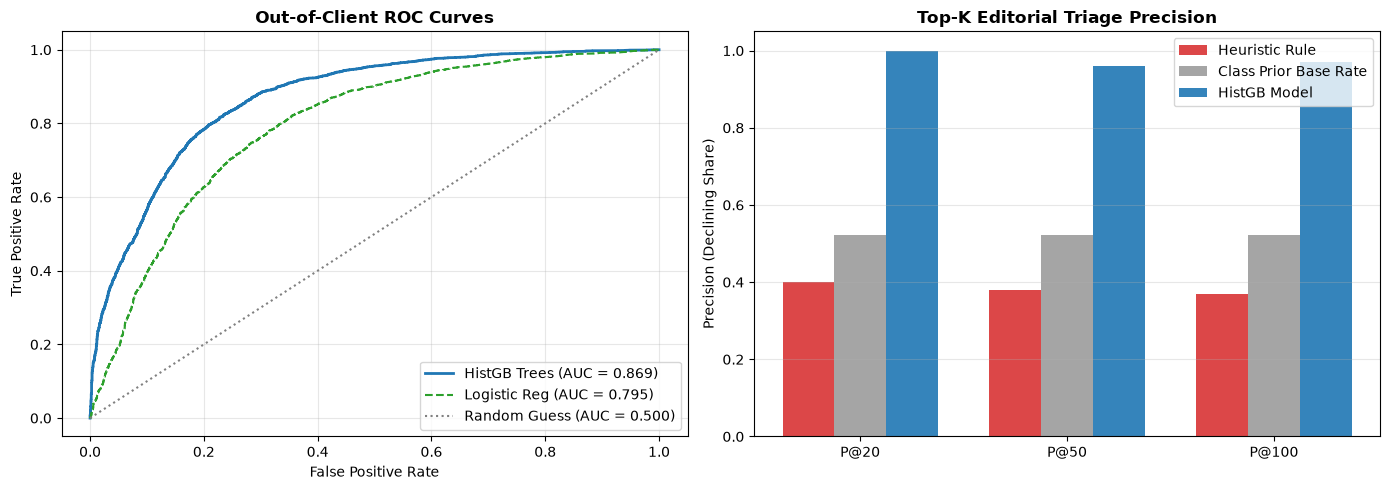

Evaluation chart saved to: c:\Users\agdig\Desktop\FlyRank Internship\Machine Learning Cohort\flyrank-internship-ml\work\outputs\capstone_model_evaluation.png
Metrics receipt saved to: c:\Users\agdig\Desktop\FlyRank Internship\Machine Learning Cohort\flyrank-internship-ml\work\outputs\capstone_metrics.json
Final recommendations queue saved to: c:\Users\agdig\Desktop\FlyRank Internship\Machine Learning Cohort\flyrank-internship-ml\work\outputs\capstone_recommendations.csv


In [10]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 1. Generate & Save Evaluation Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, test_data["pred_prob_lr"])
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, test_data["pred_prob_hgb"])

axes[0].plot(fpr_hgb, tpr_hgb, label=f"HistGB Trees (AUC = {results_summary.loc[3, 'ROC-AUC']:.3f})", color="#1f77b4", lw=2)
axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC = {results_summary.loc[2, 'ROC-AUC']:.3f})", color="#2ca02c", lw=1.5, linestyle="--")
axes[0].plot([0, 1], [0, 1], linestyle=":", color="gray", label="Random Guess (AUC = 0.500)")
axes[0].set_title("Out-of-Client ROC Curves", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Plot B: Precision@K Comparison
k_vals = ["P@20", "P@50", "P@100"]
hgb_p = [results_summary.loc[3, "Precision@20"], results_summary.loc[3, "Precision@50"], results_summary.loc[3, "Precision@100"]]
rule_p = [results_summary.loc[1, "Precision@20"], results_summary.loc[1, "Precision@50"], results_summary.loc[1, "Precision@100"]]
prior_p = [results_summary.loc[0, "Precision@20"], results_summary.loc[0, "Precision@50"], results_summary.loc[0, "Precision@100"]]

x = np.arange(len(k_vals))
width = 0.25

axes[1].bar(x - width, rule_p, width, label="Heuristic Rule", color="#d62728", alpha=0.85)
axes[1].bar(x, prior_p, width, label="Class Prior Base Rate", color="#7f7f7f", alpha=0.7)
axes[1].bar(x + width, hgb_p, width, label="HistGB Model", color="#1f77b4", alpha=0.9)
axes[1].set_title("Top-K Editorial Triage Precision", fontsize=12, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(k_vals)
axes[1].set_ylabel("Precision (Declining Share)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="upper right")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig_path = "../../work/outputs/capstone_model_evaluation.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Evaluation chart saved to: {os.path.abspath(fig_path)}")

# 2. Export Metrics JSON Receipt
metrics_dict = {
    "dataset": "FlyRank/internship-warehouse",
    "training_rows": len(train_data),
    "training_clients": int(train_data["client_hash_id"].nunique()),
    "test_rows": len(test_data),
    "test_clients": int(test_data["client_hash_id"].nunique()),
    "test_decline_prior": float(y_test.mean()),
    "models": results_summary.to_dict(orient="records"),
    "top_signals": feat_imp_df.head(5).to_dict(orient="records")
}

json_path = "../../work/outputs/capstone_metrics.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2)
print(f"Metrics receipt saved to: {os.path.abspath(json_path)}")

# 3. Export Recommendations CSV
rec_csv_path = "../../work/outputs/capstone_recommendations.csv"
ranked_capstone_queue.to_csv(rec_csv_path, index=False)
print(f"Final recommendations queue saved to: {os.path.abspath(rec_csv_path)}")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
